# Importing Libraries

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from getdist import plots, loadMCSamples
from matplotlib import cm
from matplotlib.lines import Line2D
import pandas as pd
import matplotlib.lines as mlines
from getdist import plots
from pathlib import Path

# $n_s$-r calculation

In [2]:
def phi2_final(c):
    """
    Calculates phi^2_final based on the coupling constant c (xi).
    
    Formula:
    1 / (8*c + 3*sqrt(c*(c + 18) + 9) + 9)
    """
    xi = c
    
    # Calculate the term inside the square root first
    # xi * (xi + 18) + 9
    sqrt_arg = xi * (xi + 18) + 9
    sqrt_term = np.sqrt(sqrt_arg)
    
    # Calculate the denominator
    # 8*xi + 3*sqrt(...) + 9
    denominator = 8 * xi + 3 * sqrt_term + 9
    
    return 1.0 / denominator

In [3]:
def phi2_initial(N, c):
    """
    Calculates phi^2_initial based on N and c (xi).
    
    Formula:
    (0.0909091 - 0.0909091 * exp(-7.3332 * xi * N) * (1 - 11 * xi * phi_f^2)^0.999981) / xi
    """
    # 1. Get phi_final squared
    phi_f_sq = phi2_final(c)
    
    # 2. Define xi
    xi = c
    
    # 3. Calculate the base term for the exponent
    # (1. - 11. * xi * phi_f^2)
    base_term = 1.0 - 11.0 * xi * phi_f_sq
    
    # 4. Calculate the exponential part
    # exp(-7.3332 * xi * N)
    exp_part = np.exp(-7.3332 * xi * N)
    
    # 5. Combine terms in the numerator
    # 0.0909091 * exp_part * base_term^0.999981
    term2 = 0.0909091 * exp_part * (base_term**0.999981)
    
    # Numerator: 0.0909091 - term2
    numerator = 0.0909091 - term2
    
    # 6. Final result
    return numerator / xi

In [4]:
def ns(N, s, c):
    """
    Calculates the scalar spectral index n_s based on N and c (xi)
    using specific numerical constants.
    
    Formula:
    xi * ( (7.9997 / (1. * xi * phi_i^2 + 1.)) - 13.4442 ) - (0.777776 / phi_i^2) + 0.99985
    """
    # 1. Get phi_initial squared
    phi_i_sq = phi2_initial(N, c)
    
    # 2. Define xi
    xi = c
    
    # 3. Calculate the bracket term
    # (7.9997 / (1. * xi * phi_i^2 + 1.)) - 13.4442
    denom = (1.0 * xi * phi_i_sq) + 1.0
    bracket = (7.9997 / denom) - 13.4442
    
    # 4. Calculate the main terms
    term1 = xi * bracket
    term2 = 0.777776 / phi_i_sq
    term3 = 0.99985
    
    # 5. Final result
    return term1 - term2 + term3

In [5]:
def r(N, s, c):
    """
    Calculates the tensor-to-scalar ratio r based on N and c (xi)
    using specific numerical constants.
    
    Formula:
    xi * ( 107.552 - (127.995 / (1. * xi * phi_i^2 + 1.)) ) + (0.888856 / phi_i^2)
    """
    # 1. Get phi_initial squared
    phi_i_sq = phi2_initial(N, c)
    
    # 2. Define xi
    xi = c
    
    # 3. Calculate the bracket term
    # 107.552 - (127.995 / (1. * xi * phi_i^2 + 1.))
    denom = (1.0 * xi * phi_i_sq) + 1.0
    bracket = 107.552 - (127.995 / denom)
    
    # 4. Calculate the main terms
    term1 = xi * bracket
    term2 = 0.888856 / phi_i_sq
    
    # 5. Final result
    return term1 + term2

# Loading and Plotting the P-LB-BK18 and P-ACT-LB-BK18 data sets

Loading 'P-ACT-LB-BK18' from: /home/rudranil/Work/GitHub/Non-minimally-coupled-loop-quantum-inflation-with-inverse-volume-corrections/data/p-actlite-bk-l-b_r_camb/p-actlite-bk-l-b_r_camb
Loading gridded 'P-LB-BK18' data from: /home/rudranil/Work/GitHub/Non-minimally-coupled-loop-quantum-inflation-with-inverse-volume-corrections/data/rns_code/
Gridded data loaded successfully.


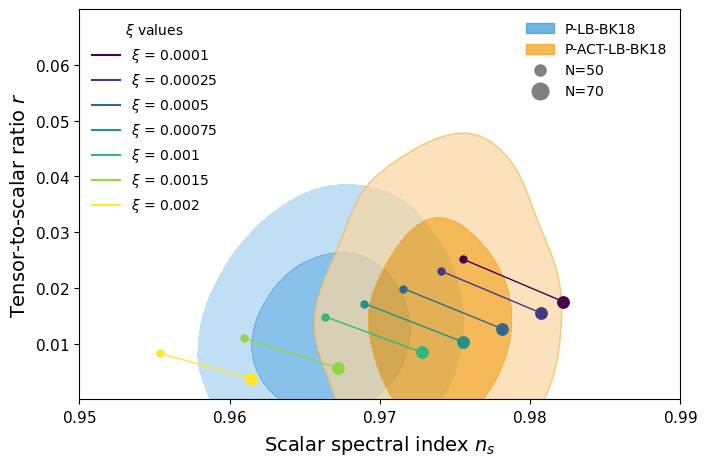

In [6]:
# This assumes the notebook is in the 'data_sets' folder (Change it according to your path)
notebook_dir = Path.cwd()

base_path = notebook_dir.parents[1] / "data"

# # 1. Path to "ACT-LB-BK18" MCMC chain
# path_act_lb = os.path.join(base_path, 'actlite-bk-l-b_r_camb/')
# root_act_lb = 'actlite-bk-l-b_r_camb'
# label_act_lb = 'ACT-LB-BK18'

# 2. Path to "P-ACT-LB-BK18" MCMC chain (Change the path of all these data sets according to your directory)
path_p_act_lb = os.path.join(base_path, 'p-actlite-bk-l-b_r_camb/')
root_p_act_lb = 'p-actlite-bk-l-b_r_camb'
label_p_act_lb = 'P-ACT-LB-BK18'

# 3. Path to "Planck+BK18+BAO" gridded data
grid_path = os.path.join(base_path, 'rns_code/')
grid_prefix = 'BK18' # Uses BK18density_xy.txt, etc.
grid_label = 'P-LB-BK18'

# --- End of paths ---


# Step 1: Load MCMC samples
samples_list = []
mcmc_labels = []

# try:
#     print(f"Loading '{label_act_lb}' from: {path_act_lb}{root_act_lb}")
#     samples_act = loadMCSamples(os.path.join(path_act_lb, root_act_lb))
#     samples_list.append(samples_act)
#     mcmc_labels.append(label_act_lb)
# except Exception as e:
#     print(f"Could not load '{label_act_lb}': {e}")

try:
    print(f"Loading '{label_p_act_lb}' from: {path_p_act_lb}{root_p_act_lb}")
    samples_p_act = loadMCSamples(os.path.join(path_p_act_lb, root_p_act_lb))
    samples_list.append(samples_p_act)
    mcmc_labels.append(label_p_act_lb)
except Exception as e:
    print(f"Could not load '{label_p_act_lb}': {e}")

# Step 2: Load the gridded "Planck+BK18+BAO" data
grid_data_loaded = False
try:
    print(f"Loading gridded '{grid_label}' data from: {grid_path}")
    xy = np.loadtxt(os.path.join(grid_path, grid_prefix + 'density_xy.txt'))
    P = np.loadtxt(os.path.join(grid_path, grid_prefix + 'density_P.txt'))
    levels = np.loadtxt(os.path.join(grid_path, grid_prefix + 'density_levels.txt'))
    
    x_grid = xy[:,0]
    y_grid = xy[:,1]
    grid_data_loaded = True
    print("Gridded data loaded successfully.")
except Exception as e:
    print(f"Could not load gridded BK18 data: {e}")
    grid_data_loaded = False

#=======================================================================================================================================

# Step 3: Create the plot
if samples_list or grid_data_loaded:
    # Set figure size
    g = plots.get_single_plotter(0.68,7) 
    
    # Get the matplotlib axes object
    ax = g.get_axes()
    
    # --- Define Colors & Alphas ---
    color_grid_fill = '#3498DB'  # Blue
    color_grid_line = '#D35400'  # Darker Orange
    alpha_grid_2s = 0.3
    alpha_grid_1s = 0.4

    color_act =   '#8E44AD'      # Purple
    alpha_act = 0.5
    
    color_p_act = '#F39C12'      # Orange
    alpha_p_act = 0.7            # trancperency
    
    
    # --- Plotting Order ---
    
    # 1. Plot the gridded data first (bottom layer)
    if grid_data_loaded:
        ax.contourf(x_grid, y_grid, P, levels, colors=[color_grid_fill], alpha=alpha_grid_2s)
        ax.contourf(x_grid, y_grid, P, levels[1:], colors=[color_grid_fill], alpha=alpha_grid_1s)
        # Plot both 1-sigma and 2-sigma lines by using `levels` and contour
        #ax.contour(x_grid, y_grid, P, levels, colors=[color_grid_line], alpha=1.0, linewidths=1.5)

    # 2. Plot the MCMC chains on top
    if samples_list:
        g.plot_2d(samples_list,
                  'ns', 'r',
                  filled=True,
                  colors=[color_p_act],
                  alphas=[alpha_p_act],
                  legend_labels=None)


    s_val = 0.500001
    C = [0.0001,0.00025,0.0005,0.00075,0.001,0.0015,0.002]  
    colorC = [cm.viridis(i) for i in np.linspace(0, 1, len(C))]

    # Loop for plotting ns-r values 
    for c_val, color in zip(C, colorC):
        # Calculate N=50 point
        ns_50 = ns(50, s_val, c_val)
        r_50 = r(50, s_val, c_val)
        
        # Calculate N=60 point
        ns_60 = ns(60, s_val, c_val)
        r_60 = r(60, s_val, c_val)

        # Calculate N=70 point
        ns_70 = ns(70, s_val, c_val)
        r_70 = r(70, s_val, c_val)
        
        # 1. Plot the line (Thick)
        ax.plot([ns_50, ns_70], [r_50, r_70], 
                color=color, linewidth=1, zorder=10)
        
        # 2. Plot N=50 point (Medium)
        ax.plot(ns_50, r_50, 'o', color=color, markersize=5, zorder=10)
        
        # 3. Plot N=60 point (Large)
        ax.plot(ns_70, r_70, 'o', color=color, markersize=8.2, zorder=10)

        # 3. Plot N=70 point (Large)
        #ax.plot(ns_70, r_70, 'o', color=color, markersize=10, zorder=10)

    # 3. Add axis labels and title
    ax.set_xlabel('Scalar spectral index $n_s$')
    ax.set_ylabel('Tensor-to-scalar ratio $r$')
    #ax.set_title(' $n_s$ vs. $r$ ')
    
    # 4. Set plot limits
    ax.set_xlim([0.95, 0.99])
    ax.set_ylim([0, 0.07])
    ax.set_xticks([0.95, 0.96, 0.97, 0.98, 0.99])
    ax.set_yticks([0.01, 0.02, 0.03, 0.04, 0.05, 0.06])

    c_legend_handles = []
    for c_val, color in zip(C, colorC):
        # Format the label, handling small numbers
        label = rf'$\xi$ = {c_val:.2g}' 
        handle = Line2D([], [], color=color, linestyle='-', label=label)
        c_legend_handles.append(handle)
    
    # Create the first legend (for C) and add it to the plot
    c_legend = ax.legend(handles=c_legend_handles, 
                         frameon=False, 
                         loc='upper left', 
                         title=r'$\xi$ values')
    ax.add_artist(c_legend)

    # 5. --- Build a manual legend ---
    legend_handles = []
    if grid_data_loaded:
        grid_patch = mpatches.Patch(color=color_grid_fill, alpha= 0.7, label=grid_label)
        legend_handles.append(grid_patch)
        
    if samples_list:
        # act_patch = mpatches.Patch(color=color_act, alpha=alpha_act, label=label_act_lb)
        p_act_patch = mpatches.Patch(color=color_p_act, alpha=alpha_p_act, label=label_p_act_lb)
        # Add them in the correct order
        # legend_handles.append(act_patch)
        legend_handles.append(p_act_patch)

    #joining line from N=50 to N=60
    n50_handle = Line2D([], [], color='gray', marker='o', linestyle='None', markersize=8, label='N=50')
    #n60_handle = Line2D([], [], color='gray', marker='o', linestyle='None', markersize=12, label='N=60')
    n70_handle = Line2D([], [], color='gray', marker='o', linestyle='None', markersize=12, label='N=70')
    
    legend_handles.extend([n50_handle, n70_handle])
    
    # Display the full, manual legend
    ax.legend(handles=legend_handles, frameon=False)

    # 6. Show the plot
    plt.savefig('1_3_spectral.pdf', dpi=300)
    plt.show()

else:
    print("\nNo data loaded, cannot create plot.")